This code is to faciltate visualization of the snow depth outputs from the ResNet model. 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
import numpy as np

In [ ]:
manual = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/labels.csv') # labels used for cam embed trainigs
#automated = pd.read_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn/predictions/results.csv')
automated = pd.read_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_allpoles_camembed_lr1e4/predictions/results.csv')

## metadata for reference
#metadata = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/pole_metadata.csv')
#metadata2 = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/snowfree_photos/BC_final_448/pole_metadata2_BC.csv')

metadata = 

In [12]:
## 
unique_cameras = pd.unique(manual['cameraID'])
print(f'{len(unique_cameras)} camera stations')

unique_cameras = pd.unique(automated['camera_id'])
print(f'{len(unique_cameras)} camera stations')

15 camera stations
15 camera stations


In [13]:
manual

,cameraID,filename,datetime,x1,y1,x2,y2,PixelLengths,SnowDepths,Storm_Flag,Vegetation_Flag,Pole_Tilt_Flag
0,BC11TLSB,BC11TLSB_WSCT1713.JPG,8/20/23 14:00,210.932727,99.281818,208.023636,309.900000,210.638271,0.506899,0,0,0
1,BC11TLSB,BC11TLSB_WSCT1724.JPG,8/23/23 16:00,208.023636,99.572727,210.350909,309.318182,209.758365,1.025626,0,0,0
2,BC11TLSB,BC11TLSB_WSCT1734.JPG,8/27/23 14:00,209.769091,100.445455,208.605455,309.900000,209.457778,1.202831,0,0,0
3,BC11TLSB,BC11TLSB_WSCT1744.JPG,8/30/23 15:00,210.932727,99.281818,210.641818,308.154545,208.872930,1.547614,0,0,0
4,BC11TLSB,BC11TLSB_WSCT1754.JPG,9/2/23 16:00,210.060000,99.281818,208.605455,309.609091,210.332302,0.687275,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
915,CP SA 5,CP SA 5_WSCT1183.JPG,8/12/23 15:00,201.041818,198.190909,195.805455,361.100000,162.993225,2.250044,0,0,0
916,CP SA 5,CP SA 5_WSCT1193.JPG,8/15/23 16:00,201.332727,200.227273,197.841818,350.918182,150.731339,11.607525,0,0,0
917,CP SA 5,CP SA 5_WSCT1203.JPG,8/19/23 14:00,202.205455,200.227273,196.678182,349.463636,149.338685,12.670308,0,0,0
918,CP SA 5,CP SA 5_WSCT1213.JPG,8/22/23 15:00,201.041818,200.518182,197.841818,358.481818,157.996046,6.063569,0,0,0


In [14]:
print(metadata2.head())
metadata2_fullpolepx = dict(zip(metadata2['camera_id'], metadata2['first_pole_length_px']))
metadata2_fullpolecm = dict(zip(metadata2['camera_id'], metadata2['pole_length_cm']))
metadata2_conversion = dict(zip(metadata2['camera_id'], metadata2['pixel_cm_conversion']))

print(metadata2_fullpolecm)
print(metadata2_fullpolepx)
print(metadata2_conversion)

  camera_id  first_pole_length_px  pole_length_cm  pixel_cm_conversion  width  \
0  BC11TLSB            212.950422      105.198324             0.494004    448   
1  BC5TLDSB            251.348148      132.861623             0.528596    448   
2  BC15TLWB            216.165030      117.813689             0.545017    448   
3   BC1TLDA            307.913222      144.654471             0.469790    448   
4   BC2TLDA            259.798106      139.471913             0.536847    448   

   height  
0     448  
1     448  
2     448  
3     448  
4     448  
{'BC11TLSB': 105.19832374752728, 'BC5TLDSB': 132.86162321968072, 'BC15TLWB': 117.8136891854132, 'BC1TLDA': 144.65447089769137, 'BC2TLDA': 139.47191342398054, 'BC3': 134.97344648276703, 'BC8TLSA': 125.53813231667245, 'BC13TLWA': 125.81987263093188, 'BC7TLEB': 129.75993108617314, 'CP MA 12 part fail': 125.35991269042334, 'CP DB 6': 147.71495015384124, 'CP DB 15': 139.66266248824869, 'CP BA 2': 145.6547696069812, 'CP EA 4 part fail': 113.92

In [15]:
## add in snowdepths2 wiht the fresh metadata 
snowdepth2_list = []

for i in range(0,len(manual['PixelLengths'])):
    pixel_length = manual['PixelLengths'].iloc[i]  # Get actual pixel length, not index
    camera_id = manual['cameraID'].iloc[i]
    snow_free_pole_cm = metadata2_fullpolecm[camera_id]
    conversion = metadata2_conversion[camera_id]
    snowdepth2 = snow_free_pole_cm - conversion*pixel_length
    snowdepth2_list.append(snowdepth2)

manual['SnowDepths2'] = snowdepth2_list
    

In [21]:
### 
automated['snow_depth'] = [0 if i < 0 else i for i in automated['snow_depth']]

In [22]:
## add in snowdepths2 wiht the fresh metadata 
snowdepth2_list = []

for i in range(0,len(automated['total_length_pixel'])):
    pixel_length = automated['total_length_pixel'].iloc[i]  # Get actual pixel length, not index
    camera_id = automated['camera_id'].iloc[i]
    snow_free_pole_cm = metadata2_fullpolecm[camera_id]
    conversion = metadata2_conversion[camera_id]
    snowdepth2 = snow_free_pole_cm - conversion*pixel_length
    snowdepth2_list.append(snowdepth2)

automated['snow_depth2'] = snowdepth2_list
    

In [23]:
automated
#automated.to_csv('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn/predictions/results2.csv')


,Unnamed: 0,camera_id,filename,datetime,x1_pred,y1_pred,x2_pred,y2_pred,total_length_pixel,snow_depth,snow_depth2
0,0,CP MA 12 part fail,CP MA 12 part fail_WSCT0791.JPG,2022-10-28 15:00:00,216.42451,64.819040,210.67975,395.75714,330.987976,0.000000,-10.089036
1,1,CP DB 6,CP DB 6_WSCT1110.JPG,2023-05-09 14:00:00,262.82007,110.400860,265.43112,426.53317,316.143097,0.000000,-9.635221
2,2,CP DB 15,CP DB 15_WSCT1632.JPG,2023-08-30 14:00:00,164.33168,160.773220,161.42114,417.13850,256.381775,17.626483,-9.712312
3,3,CP BA 2,CP BA 2_WSCT1391.JPG,2023-05-17 14:00:00,210.66963,120.594030,209.28020,420.99063,300.399811,2.253051,-4.000933
4,4,CP EA 4 part fail,CP EA 4 part fail_WSCT0517.JPG,2022-10-28 15:00:00,191.75713,86.137650,192.99179,446.43695,360.301422,0.000000,-16.451759
...,...,...,...,...,...,...,...,...,...,...,...
9947,9947,BC7TLEB,BC7TLEB_WSCT1262.JPG,2023-06-18 15:00:00,188.19480,91.136780,188.95523,425.98462,334.848694,0.000000,-8.919874
9948,9948,BC7TLEB,BC7TLEB_WSCT1289.JPG,2023-06-27 15:00:00,189.29400,91.123825,189.86299,428.15497,337.031616,0.000000,-9.823946
9949,9949,BC7TLEB,BC7TLEB_WSCT0829.JPG,2023-01-25 13:00:00,192.33215,84.733840,191.71048,364.72882,279.995697,0.000000,13.797858
9950,9950,BC7TLEB,BC7TLEB_WSCT0815.JPG,2023-01-20 14:00:00,192.19847,82.200540,191.90870,348.17220,265.971832,0.000000,19.605934


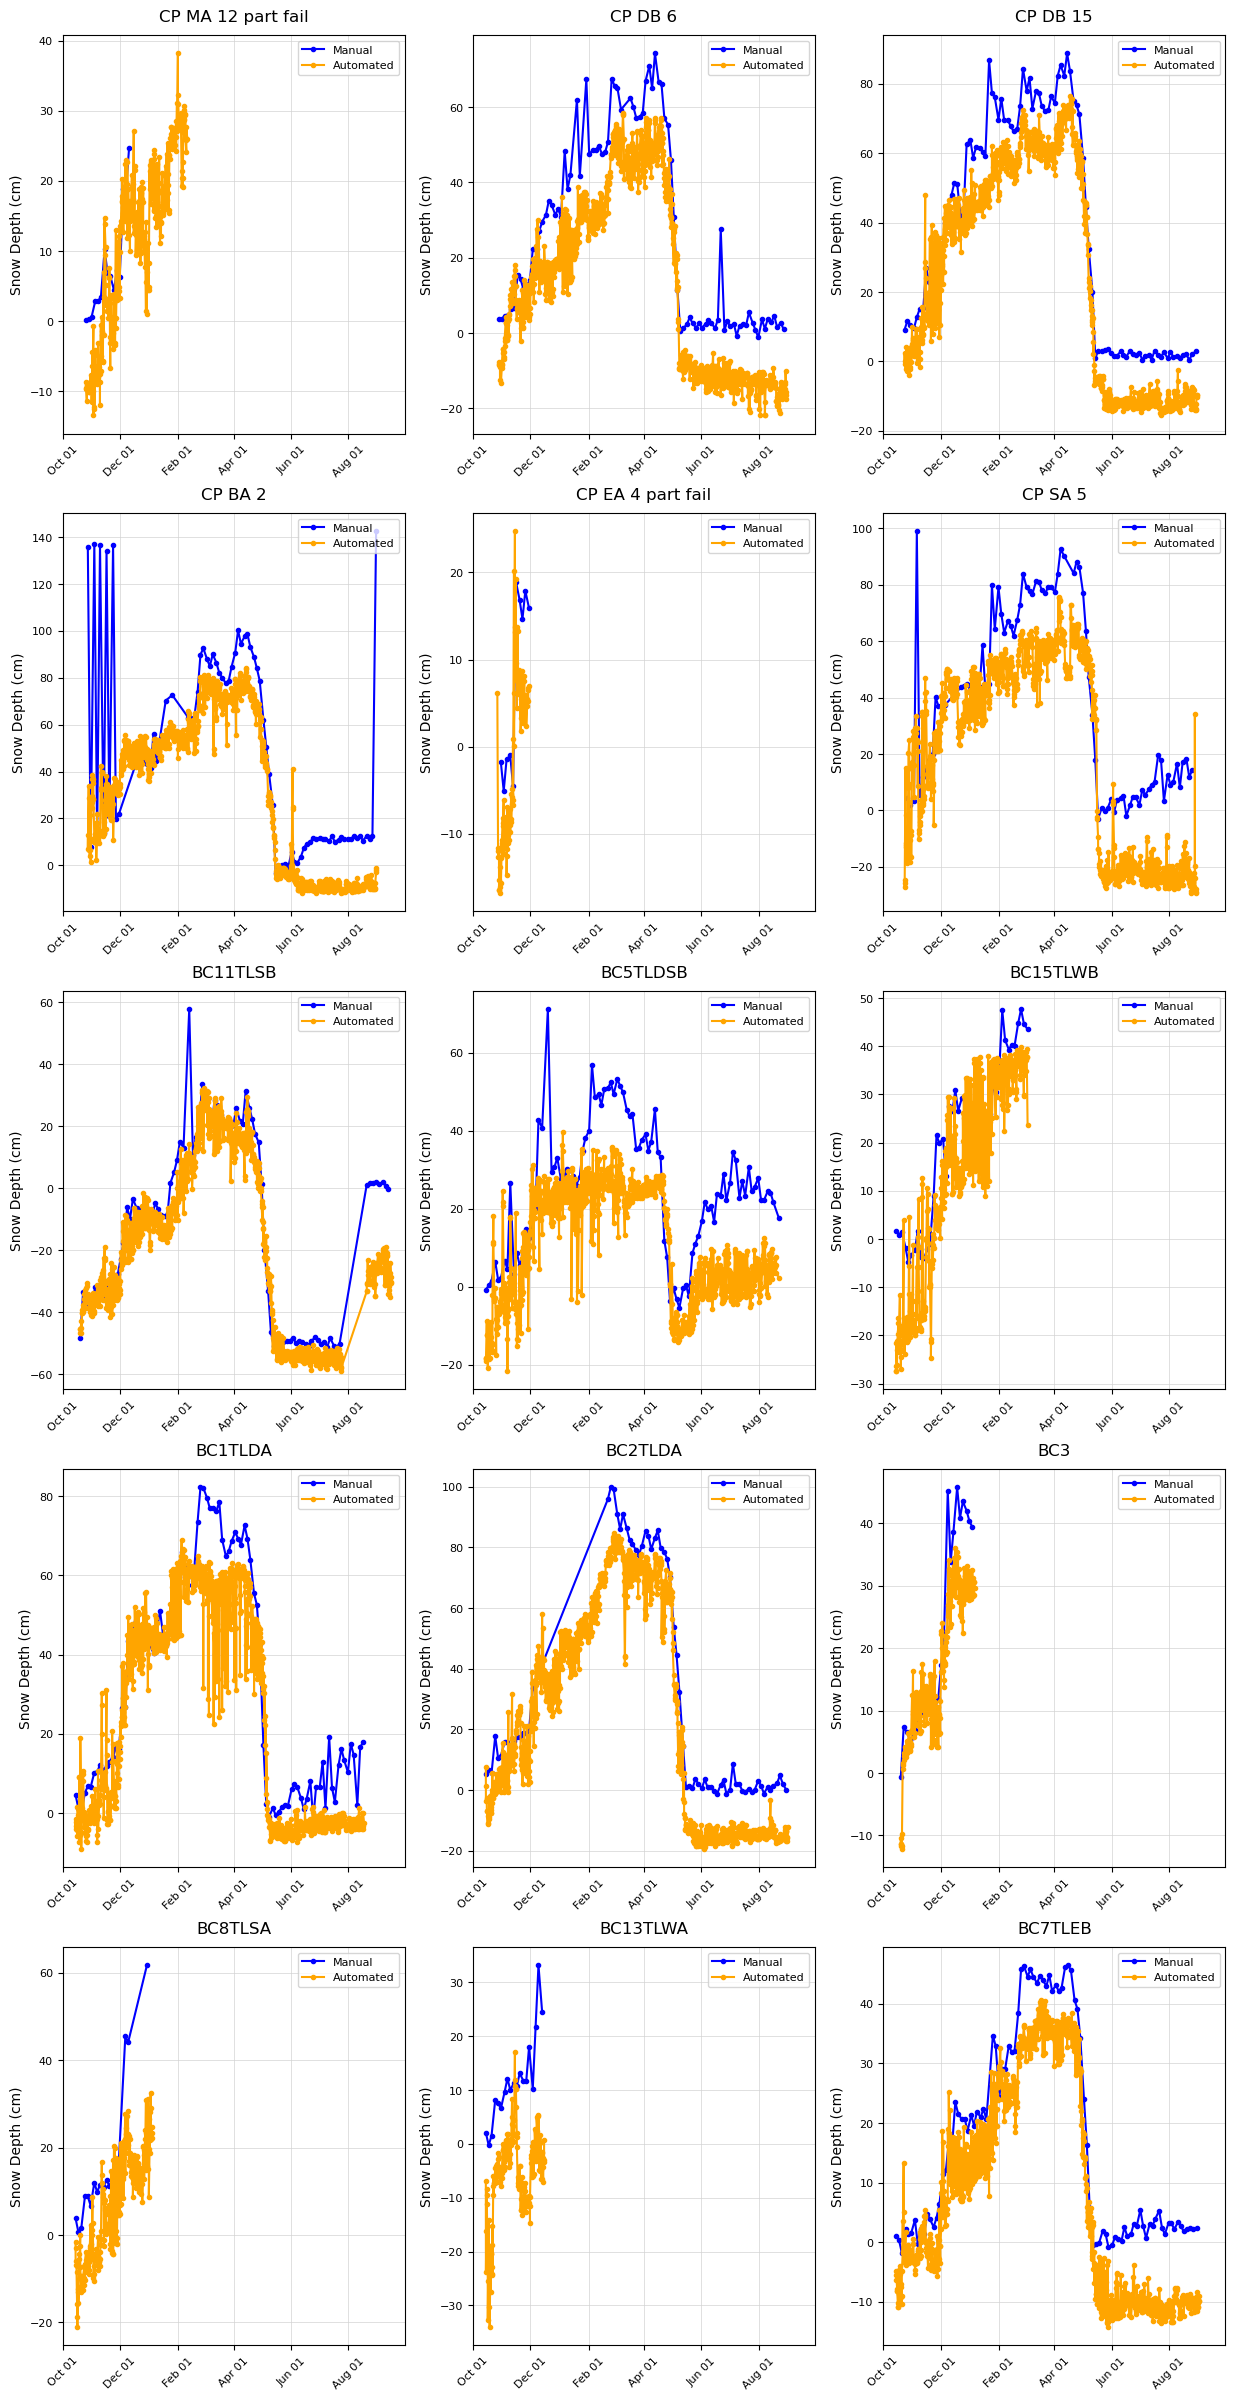

In [24]:


# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define x-axis limits and tick locations
x_min = datetime(2022, 10, 1)
x_max = datetime(2023, 9, 30)
tick_dates = [
    datetime(2022, 10, 1),
    datetime(2022, 12, 1),
    datetime(2023, 2, 1),
    datetime(2023, 4, 1),
    datetime(2023, 6, 1),
    datetime(2023, 8, 1)
]


fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes_flat = axes.flatten() # flatten axes for easier indexign

# Plot each camera's data
for i, camera_id in enumerate(unique_cameras):
    camera_dataM = manual[manual['cameraID'] == camera_id].sort_values('datetime')
    camera_dataA = automated[automated['camera_id'] == camera_id].sort_values('datetime')

    
    # Plot on the corresponding subplot
    ax = axes_flat[i]
    ax.plot(camera_dataM['datetime'], camera_dataM['SnowDepths2'], 
            color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
    ax.plot(camera_dataA['datetime'], camera_dataA['snow_depth2'], 
            color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')
    
    # Customize subplot
    ax.set_title(f'{camera_id}', fontsize=12, pad=10)
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Snow Depth (cm)', fontsize=10)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    #ax.set_ylim(0, 140)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(tick_dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax.legend(loc='upper right', fontsize=8)

In [33]:
automated['snow_depth_clean'] = [0 if i < 0 else i for i in automated['snow_depth2']]

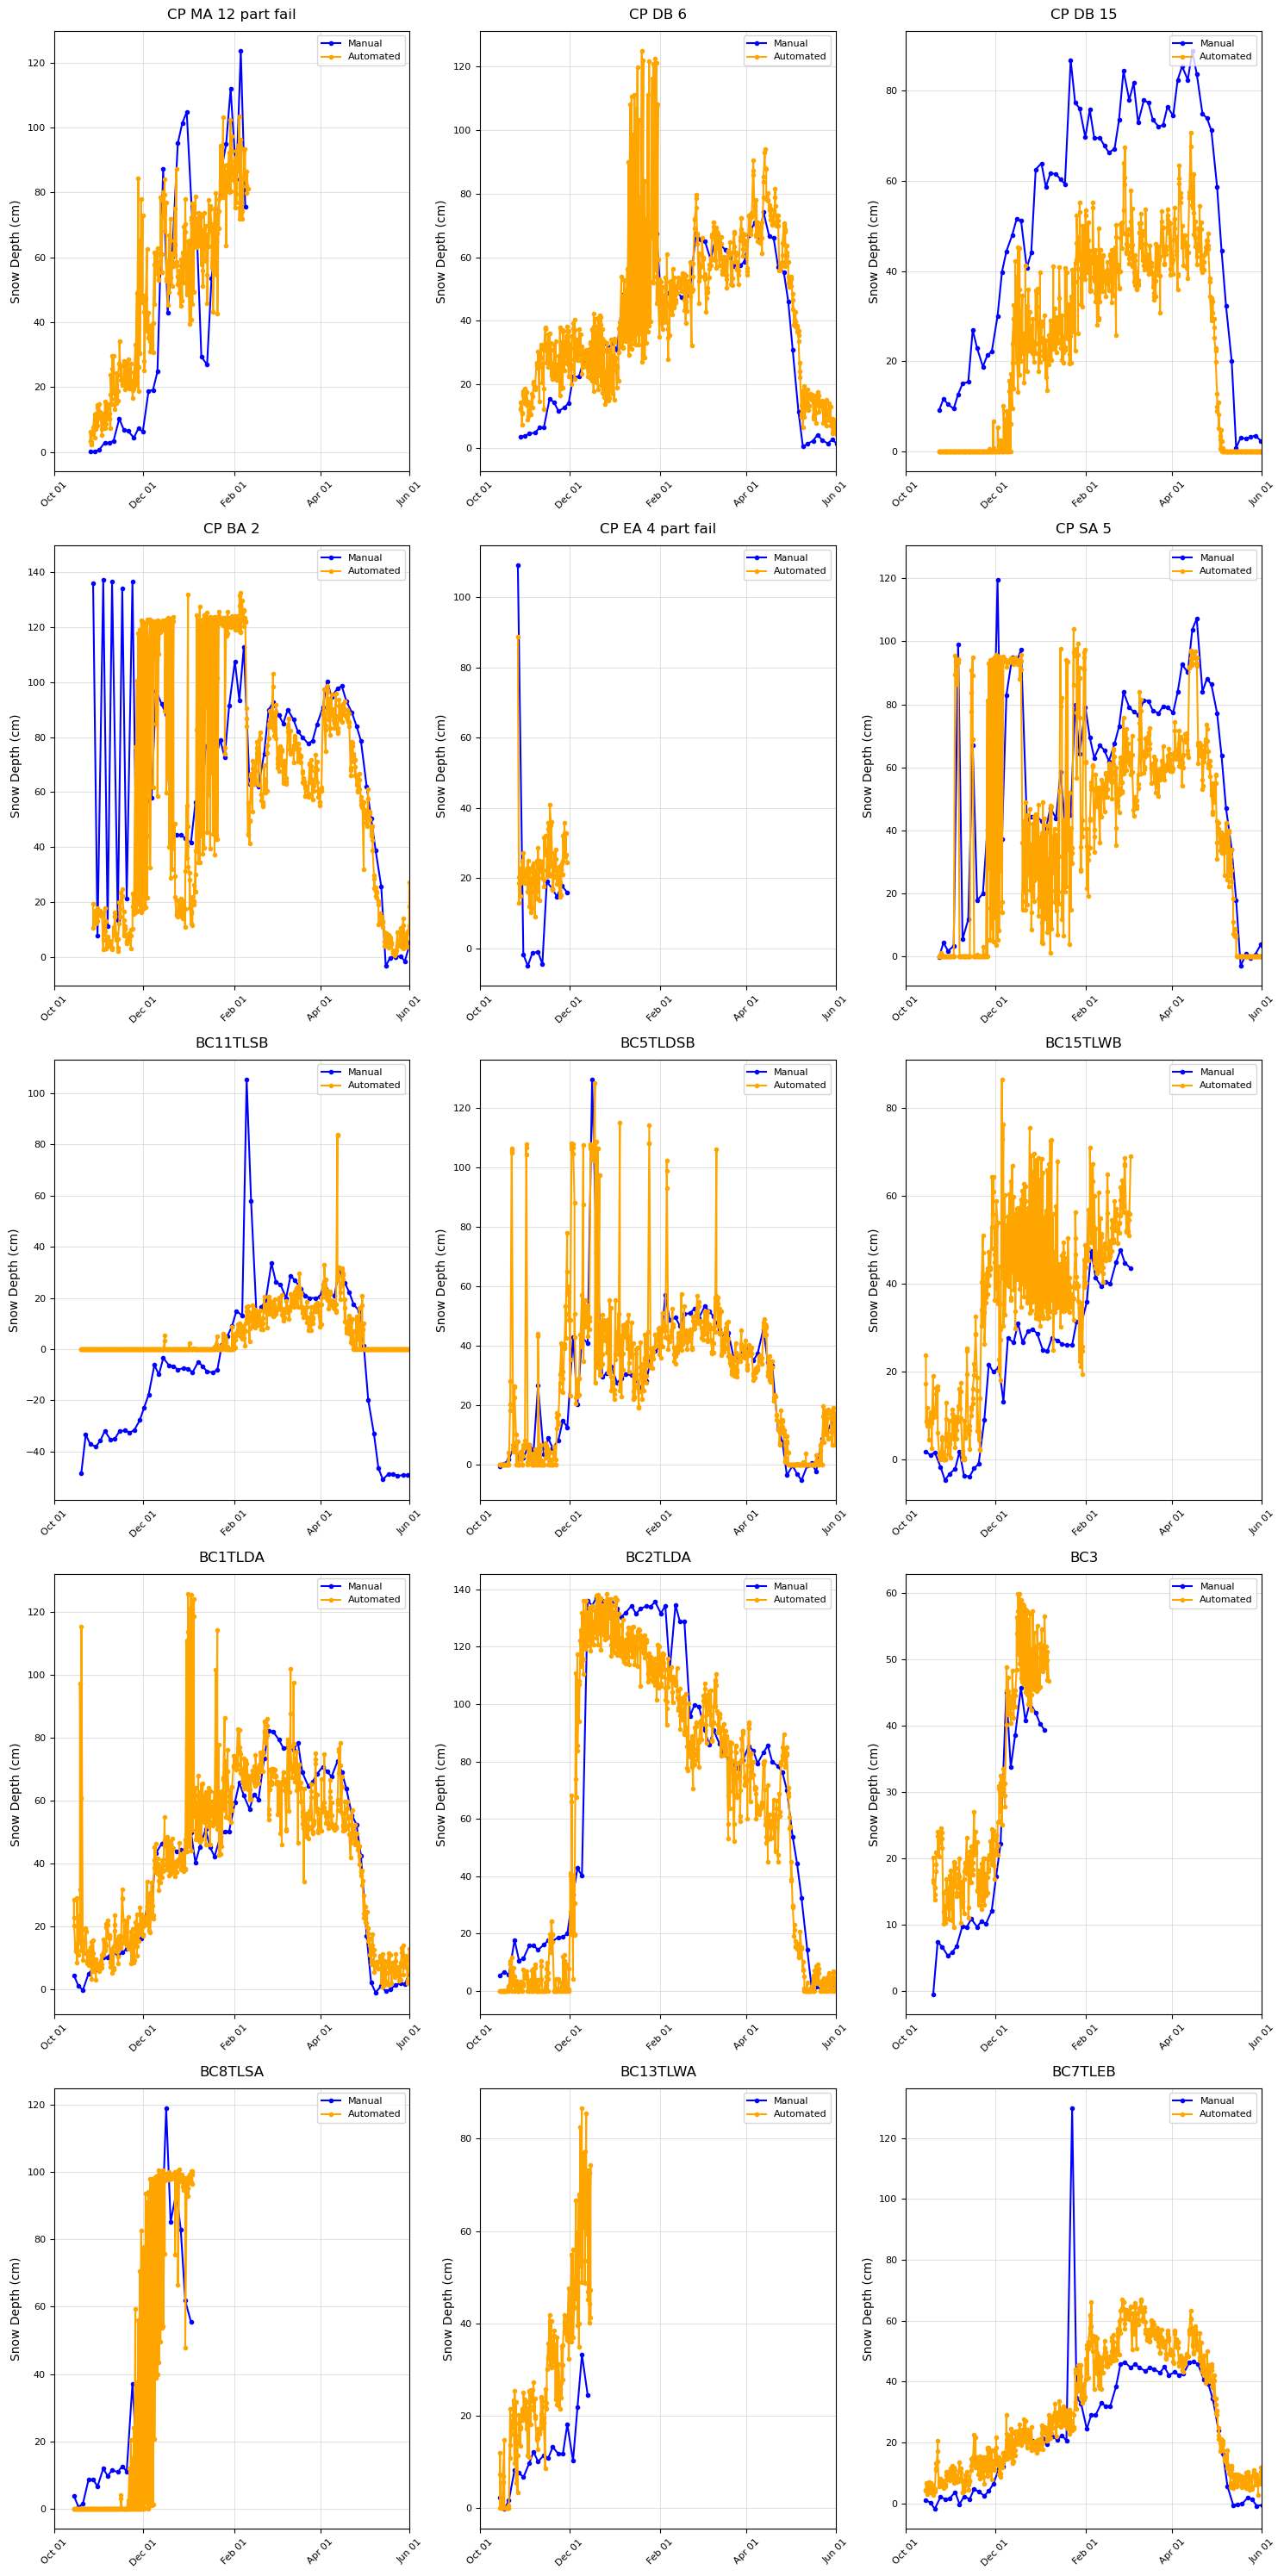

In [50]:
# Convert datetime column to proper datetime format
manual['datetime'] = pd.to_datetime(manual['datetime'])
automated['datetime'] = pd.to_datetime(automated['datetime'])

# Define x-axis limits and tick locations - October 1 to June 1
x_min = datetime(2022, 10, 1)
x_max = datetime(2023, 6, 1)
tick_dates = [
    datetime(2022, 10, 1),
    datetime(2022, 12, 1),
    datetime(2023, 2, 1),
    datetime(2023, 4, 1),
    datetime(2023, 6, 1)
]

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes_flat = axes.flatten() # flatten axes for easier indexing

# Plot each camera's data
for i, camera_id in enumerate(unique_cameras):
    camera_dataM = manual[manual['cameraID'] == camera_id].sort_values('datetime')
    camera_dataA = automated[automated['camera_id'] == camera_id].sort_values('datetime')

    # Plot on the corresponding subplot
    ax = axes_flat[i]
    ax.plot(camera_dataM['datetime'], camera_dataM['SnowDepths2'], 
            color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
    ax.plot(camera_dataA['datetime'], camera_dataA['snow_depth_clean'], 
            color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')
    
    # Customize subplot
    ax.set_title(f'{camera_id}', fontsize=12, pad=10)
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Snow Depth (cm)', fontsize=10)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(tick_dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [79]:
# Initialize the flag column
manual['storm_flag'] = np.nan

# Group by camera and flag storm measurements
for camera_id, group in manual.groupby('cameraID'):
    # Get the full pole length in pixels for this camera
    full_pole_length_cm = metadata2_fullpolecm[camera_id]  # Use pixel dictionary, not cm
    
    # Define a threshold (e.g., within 5 pixels of full pole length)
    threshold = 10  # pixels - adjust as needed
    
    # Flag measurements that are close to the full pole length
    storm_mask = abs(group['SnowDepths2'] - full_pole_length_cm) <= threshold
    
    # Update the flag column for this camera's data
    manual.loc[group.index[storm_mask], 'storm_flag'] = 1

# Print summary
print("Storm flag summary:")
print(manual['storm_flag'].value_counts())
print(f"\nFlagged {manual['storm_flag'].sum()} out of {len(manual)} measurements")

# Optional: Print flagged measurements by camera
print("\nFlagged measurements by camera:")
flagged_summary = manual[manual['storm_flag'] == 1].groupby('cameraID').size()
for camera_id, count in flagged_summary.items():
    total_for_camera = len(manual[manual['cameraID'] == camera_id])
    print(f"{camera_id}: {count} flagged out of {total_for_camera} total")

Storm flag summary:
storm_flag
1.0    30
Name: count, dtype: int64

Flagged 30.0 out of 1001 measurements

Flagged measurements by camera:
BC11TLSB: 1 flagged out of 92 total
BC2TLDA: 18 flagged out of 97 total
BC5TLDSB: 1 flagged out of 94 total
BC7TLEB: 1 flagged out of 97 total
BC8TLSA: 1 flagged out of 25 total
CP BA 2: 5 flagged out of 93 total
CP EA 4 part fail: 1 flagged out of 11 total
CP MA 12 part fail: 1 flagged out of 33 total
CP SA 5: 1 flagged out of 94 total


In [80]:
# Initialize the flag column
automated['storm_flag'] = np.nan

# Group by camera and flag storm measurements
for camera_id, group in automated.groupby('camera_id'):
    # Get the full pole length in pixels for this camera
    full_pole_length_cm = metadata2_fullpolecm[camera_id]  # Use pixel dictionary, not cm
    
    # Define a threshold (e.g., within 5 pixels of full pole length)
    threshold = 10  # pixels - adjust as needed
    
    # Flag measurements that are close to the full pole length
    storm_mask = abs(group['snow_depth2'] - full_pole_length_cm) <= threshold
    
    # Update the flag column for this camera's data
    automated.loc[group.index[storm_mask], 'storm_flag'] = 1

# Print summary
print("Storm flag summary:")
print(automated['storm_flag'].value_counts())
print(f"\nFlagged {automated['storm_flag'].sum()} out of {len(automated)} measurements")

# Optional: Print flagged measurements by camera
print("\nFlagged measurements by camera:")
flagged_summary = automated[automated['storm_flag'] == 1].groupby('camera_id').size()
for camera_id, count in flagged_summary.items():
    total_for_camera = len(automated[automated['camera_id'] == camera_id])
    print(f"{camera_id}: {count} flagged out of {total_for_camera} total")

Storm flag summary:
storm_flag
1.0    30
Name: count, dtype: int64

Flagged 30.0 out of 9937 measurements

Flagged measurements by camera:
BC2TLDA: 29 flagged out of 967 total
BC5TLDSB: 1 flagged out of 931 total


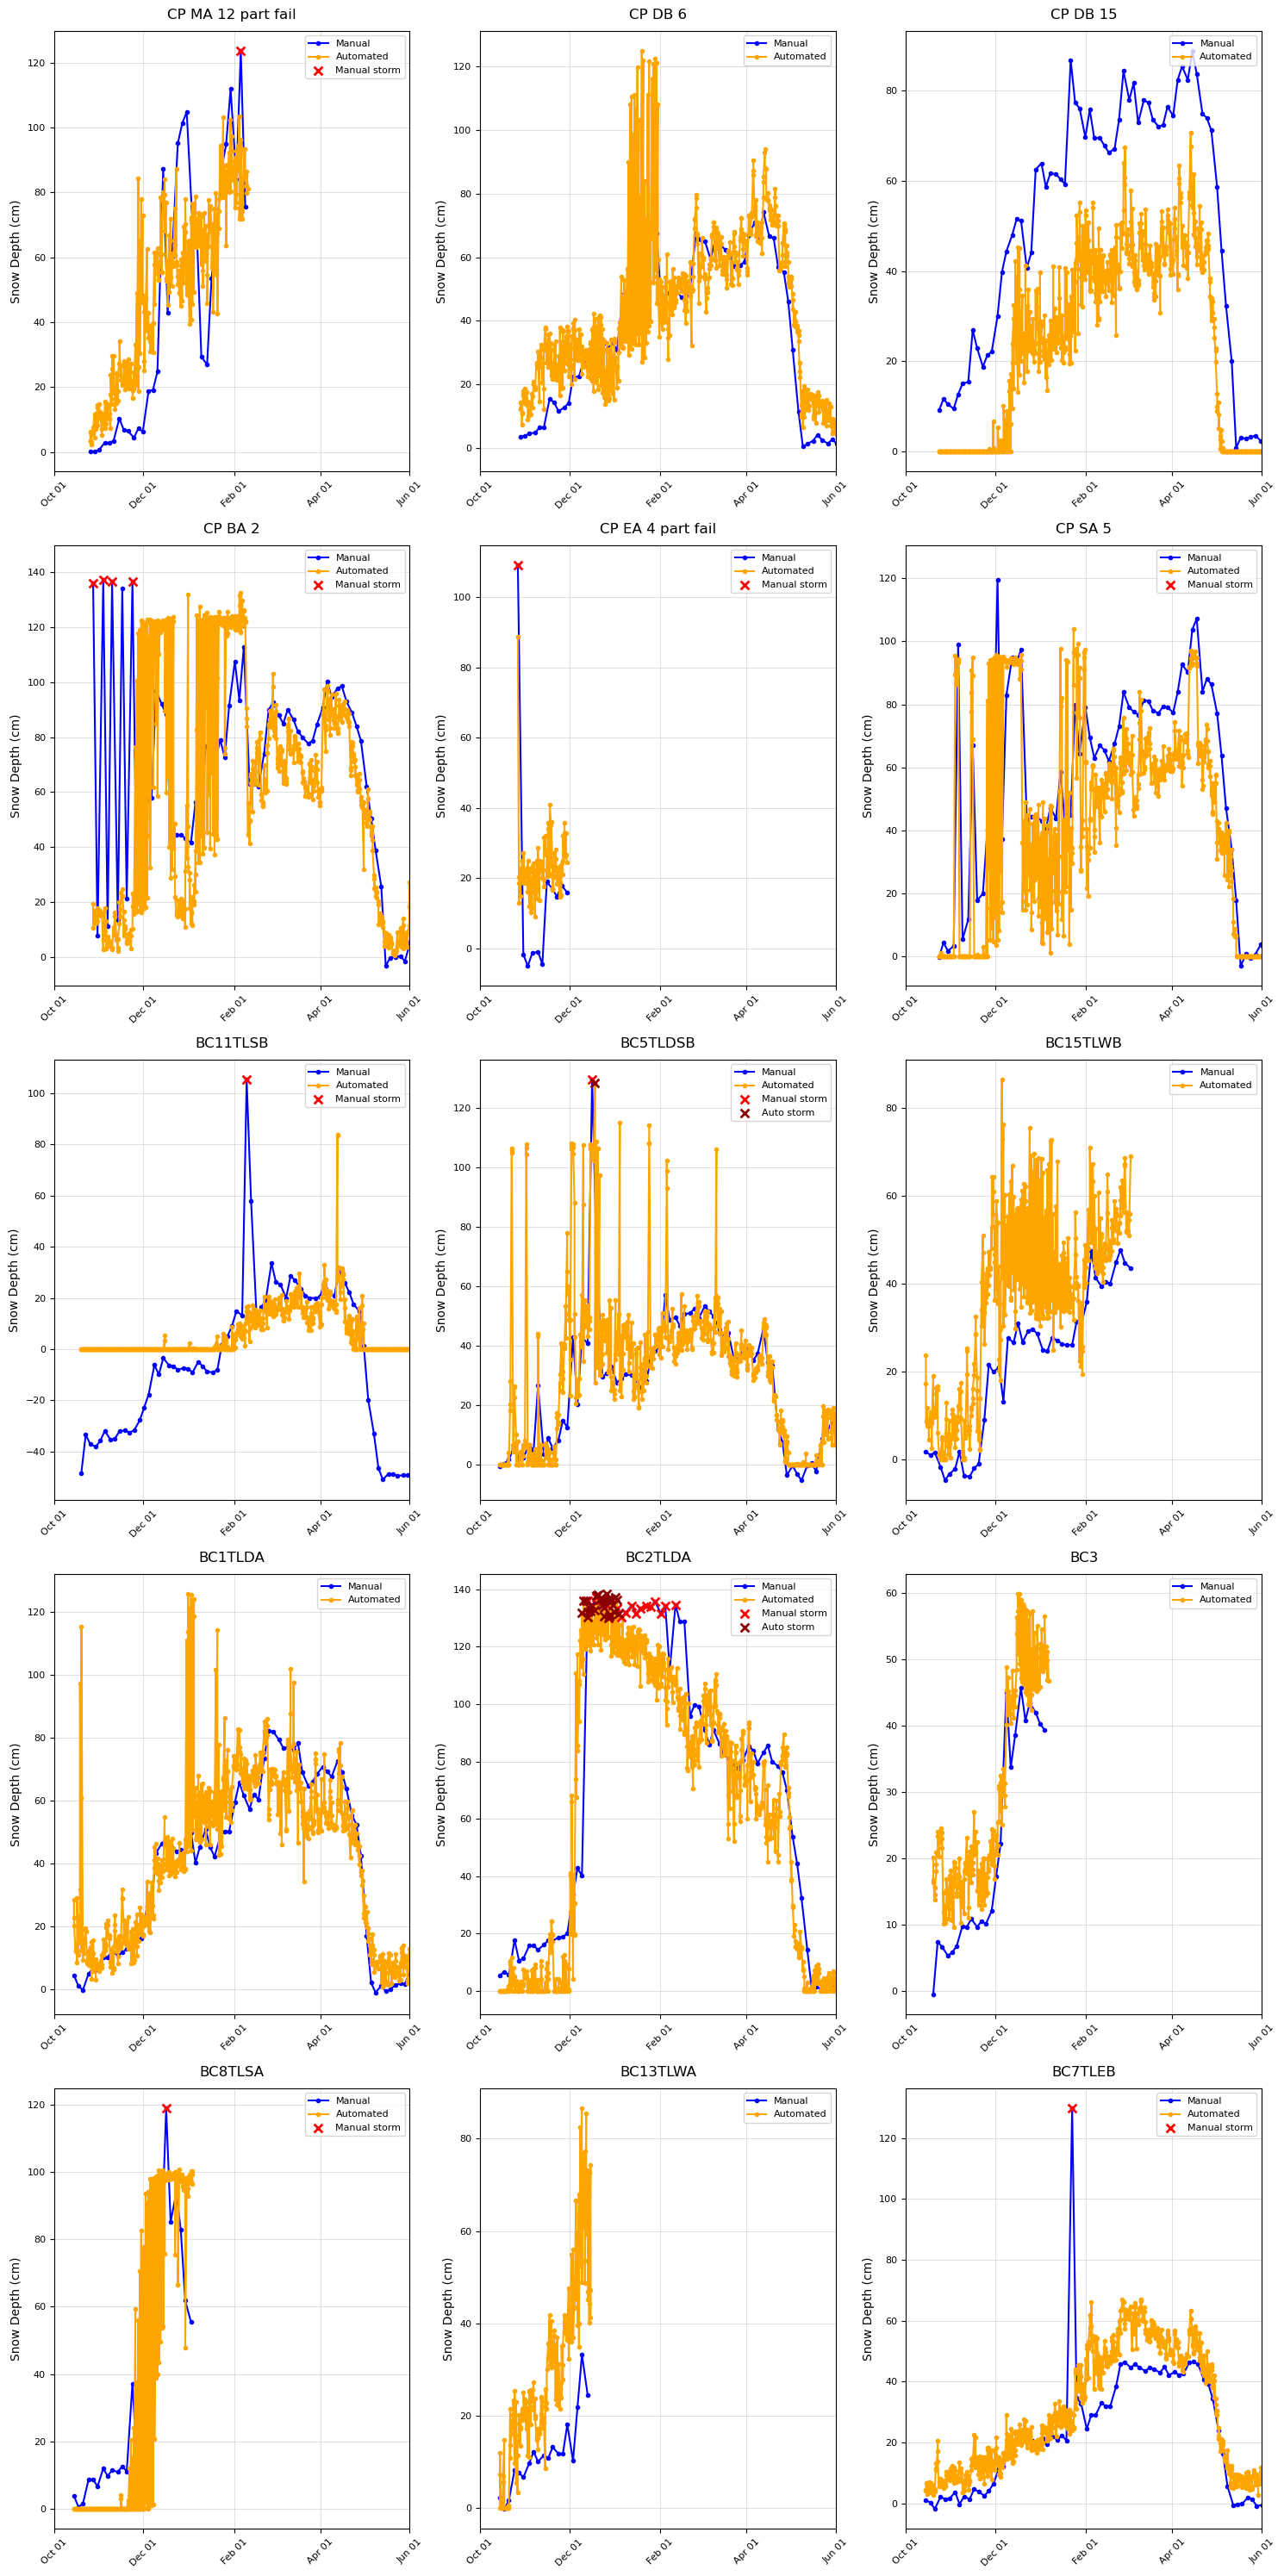

In [81]:
fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes_flat = axes.flatten() # flatten axes for easier indexing

# Plot each camera's data
for i, camera_id in enumerate(unique_cameras):
    camera_dataM = manual[manual['cameraID'] == camera_id].sort_values('datetime')
    camera_dataA = automated[automated['camera_id'] == camera_id].sort_values('datetime')

    # Plot on the corresponding subplot
    ax = axes_flat[i]
    
    # Plot regular data
    ax.plot(camera_dataM['datetime'], camera_dataM['SnowDepths2'], 
            color='blue', linewidth=1.5, marker='o', markersize=3, label='Manual')
    ax.plot(camera_dataA['datetime'], camera_dataA['snow_depth_clean'], 
            color='orange', linewidth=1.5, marker='o', markersize=3, label='Automated')
    
    # Filter for storm-flagged points only
    storm_manual = camera_dataM[camera_dataM['storm_flag'] == 1]
    storm_automated = camera_dataA[camera_dataA['storm_flag'] == 1]
    
    # Plot the storm-flagged points at their actual snow depth values
    if not storm_manual.empty:
        ax.scatter(storm_manual['datetime'], storm_manual['SnowDepths2'], 
                color='red', s=50, marker='x', linewidth=2, label='Manual storm', zorder=10)
    
    if not storm_automated.empty:
        ax.scatter(storm_automated['datetime'], storm_automated['snow_depth_clean'], 
                color='darkred', s=50, marker='x', linewidth=2, label='Auto storm', zorder=10)
    
    # Customize subplot
    ax.set_title(f'{camera_id}', fontsize=12, pad=10)
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Snow Depth (cm)', fontsize=10)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(tick_dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # Only show legend items that actually appear in the plot
    handles, labels = ax.get_legend_handles_labels()
    if handles:  # Only create legend if there are items to show
        by_label = dict(zip(labels, handles))  # Remove duplicate labels
        ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()